*(CU Boulder GEOL 3600 November 2025)*

# How to make a `.gif` animation from individual frames

Animations can be powerful ways to communicate concepts and analyze data. This notebook introduces one of many different methods for creating animations using Python code and associated packages. In this case, the goal is to make a Graphics Interchange Format (GIF) file from a series of individual images. Note that a GIF animation isn't a "true" movie-type animation; it is really just a collection of images, without embedded information about frame rate. But its simplicity can also be a strength: it tends to be supported across operating systems, works well with slide-show software, and is straightforward to host on websites or post on social media channels.

This example uses the `imageio` library. (See: [https://imageio.readthedocs.io/en/stable/](https://imageio.readthedocs.io/en/stable/))

## Overview of the method

1. Write code that generates a time sequence of images. They could be scatter plots, satellite images, photos, or any other kind of graphical image.
2. Save each image to a file, in a standard image-file format such as Portable Network Graphics (PNG), in such a way that the files are numbered sequentially. For example, `frame01.png`, `frame02.png`, etc.
3. Use a 3rd-party package, such as the Python package `imagio`, to stitch the frames into a single `.gif` file.

## A Worked example

The following example creates a simulation of a ball undergoing a random walk. The simulation will iterate through a series of steps. At each step, the ball will move by one step in a random direction (determined by drawing a pseudo-random number). At each step, a file will be saved in PNG format.

### Part 1: Generating and saving frames

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Define a function to plot the ball
def plot_ball(x, y, marker='ro'):
    plt.cla()
    plt.plot(x, y, marker)
    plt.xlim(domain_extent)
    plt.ylim(domain_extent)

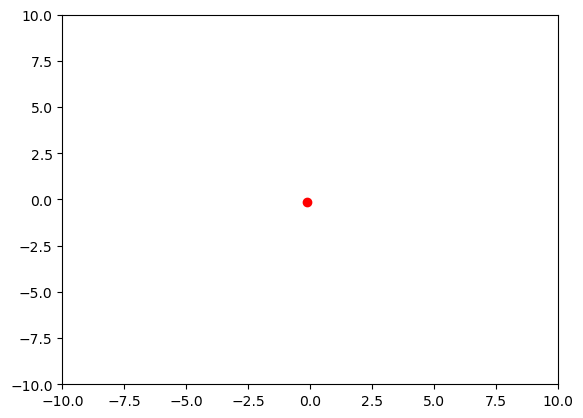

In [10]:
# INITIALIZE
frame_filename = "ball"
num_steps = 12
step_size = 1.0
domain_extent = [-10, 10]
x = 0.0 # initial x position
y = 0.0 # initial y position

# Plot and save the initial position
plot_ball(x, y)
plt.savefig(frame_filename + "0.png")

# PROCESS
for i in range(1, num_steps + 1):

    # Take a step
    step_direction = 2 * np.pi * np.random.rand()
    x += np.cos(step_direction)
    y += np.sin(step_direction)

    # Clear the plot and plot the new position
    plot_ball(x, y)

    # Save the image to a file
    plt.savefig(frame_filename + str(i).zfill(3) + ".png")


The pyplot function [`savefig()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html) will save the current figure to a file with the file name that you assign. `savefig()` will determine the file format based on the file extension that you give it. In this example, the extension `.png` tells `savefig()` to use PNG format.

Check that we have a series of frame files:

In [11]:
!ls ball*.png

ball0.png   ball005.png ball010.png ball11.png  ball5.png
ball001.png ball006.png ball011.png ball12.png  ball6.png
ball002.png ball007.png ball012.png ball2.png   ball7.png
ball003.png ball008.png ball1.png   ball3.png   ball8.png
ball004.png ball009.png ball10.png  ball4.png   ball9.png


There are a couple of problems here:

1. Although it isn't obvious from the listing, the starting configuration that we saved to a file called `ball0.png` got overwritten in the first pass through the loop, when `i = 0`.
   
2. We want the files to be in alphabetical order, but they aren't. Instead, frame 10 comes right after frame 1.



**EXERCISE**: Make a copy of the above code that fixes the first problem.

<details>
    <summary>(Click here to see one possible solution.)</summary>
    
    # INITIALIZE
    frame_filename = "ball"
    num_steps = 12
    step_size = 1.0
    domain_extent = [-10, 10]
    x = 0.0 # initial x position
    y = 0.0 # initial y position
    
    # Plot and save the initial position
    plot_ball(x, y)
    plt.savefig(frame_filename + "0.png")
    
    # PROCESS
    for i in range(1, num_steps + 1):
    
        # Take a step
        step_direction = 2 * np.pi * np.random.rand()
        x += np.cos(step_direction)
        y += np.sin(step_direction)
    
        # Clear the plot and plot the new position
        plot_ball(x, y)
    
        # Save the image to a file
        plt.savefig(frame_filename + str(i) + ".png")

    
</details>




To solve the second problem - that is, to get the files in correct alphabetical order - one approach is to use the Python `string` method [`zfill()`](https://docs.python.org/3/library/stdtypes.html#str.zfill). 

`zfill()` is designed to add leading zeros to a string that represents a number. You pass it the desired number of digits (characters), and it adds as many `0` characters as needed to bring the total length of the string to the desired value.

Examples:

In [7]:
"42".zfill(5)

'00042'

In [8]:
str(12).zfill(3)

'012'

In [9]:
str(512).zfill(3) # will not add anything because there are already 3 digits

'512'

**EXERCISE**: Make a copy of the frame-generating code above, and modify it such that the frame file numbers always have 3 digits.

<details>
    <summary>(Click here for a hint.)</summary>
Modify the call to `savefig()` as follows:

    plt.savefig(frame_filename + str(i).zfill(3) + ".png")
</details>

### Part 2: Stitching the frames together

Once you have frames as files, you can combine them into a single GIF animation file using the `imageio` package.

`imageio` provides a function called `imread()` that will read the contents of an image-format file. It also provides a function called `mimsave` that takes a string and a list of image objects, and creates a GIF animation with the given filename.

As with most programming tasks, there are several ways to approach this.

One method is to copy our frame-creation code from above, but this time add a step to the loop where we:

1. Use `imread()` to read in the file just created as an image.
2. Append it to a list of images.
3. After the loop has completed, call `mimsave()`, passing a name for the GIF file to be created, and the list of images.


**EXERCISE:** try this!

/var/folders/r1/8sz6r01s2yj06sxwxwcl3m340000gn/T/ipykernel_40168/907761937.py:34: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(this_frame_name))


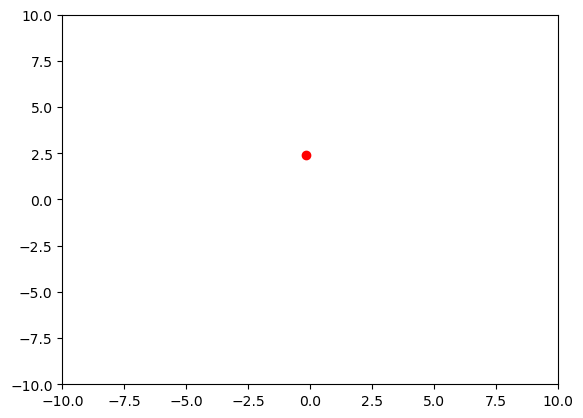

In [12]:
import imageio

# (your code here)
# INITIALIZE
frame_filename = "ball"
gif_filename = "moving_ball.gif"
num_steps = 12
step_size = 1.0
domain_extent = [-10, 10]
x = 0.0 # initial x position
y = 0.0 # initial y position
images = []

# Plot and save the initial position
plot_ball(x, y)
plt.savefig(frame_filename + "0.png")

# PROCESS
for i in range(num_steps):

    # Take a step
    step_direction = 2 * np.pi * np.random.rand()
    x += np.cos(step_direction)
    y += np.sin(step_direction)

    # Clear the plot and plot the new position
    plot_ball(x, y)

    # Save the image to a file
    this_frame_name = frame_filename + str(i) + ".png"
    plt.savefig(this_frame_name)

    # Add the image to the list
    images.append(imageio.imread(this_frame_name))

# FINALIZE

# Create a .gif animation file
imageio.mimsave(gif_filename, images)

<details>
    <summary>(Click here to view a potential solution.)</summary>
    
    # INITIALIZE
    frame_filename = "ball"
    gif_filename = "moving_ball.gif"
    num_steps = 12
    step_size = 1.0
    domain_extent = [-10, 10]
    x = 0.0 # initial x position
    y = 0.0 # initial y position
    images = []
    
    # Plot and save the initial position
    plot_ball(x, y)
    plt.savefig(frame_filename + "0.png")
    
    # PROCESS
    for i in range(num_steps):
    
        # Take a step
        step_direction = 2 * np.pi * np.random.rand()
        x += np.cos(step_direction)
        y += np.sin(step_direction)
    
        # Clear the plot and plot the new position
        plot_ball(x, y)
    
        # Save the image to a file
        this_frame_name = frame_filename + str(i) + ".png"
        plt.savefig(this_frame_name)
    
        # Add the image to the list
        images.append(imageio.imread(this_frame_name))
    
    # FINALIZE
    
    # Create a .gif animation file
    imageio.mimsave(gif_filename, images)
</details>


### Part 3: Viewing the image

If we want to view the animation inside a notebook, one method is to use the `IPython.display` class `Image`, as follows:

In [ ]:
from IPython.display import Image

In [ ]:
Image(gif_filename)

This is just one of many ways to create and display an animation using Python. More to come!